# 🤖 Notebook 4 — Complaint Routing Model (Vectorization & Classification)

**Project:** AI-Driven Citizen Grievance Analysis

**Input:** data/processed/grievance_processed.csv ← from Notebook 2

**Output:** Trained models saved to `models/` folder

### What this notebook does:
- Data Consolidation: Maps 17+ granular complaint types into 3-5 core government departments to mitigate class imbalance.
- Label Encoding: Converts categorical department names into numerical labels for algorithmic processing.
- TF-IDF Vectorization: Transforms cleaned text into numerical feature matrices using unigrams and bigrams.
- Supervised Learning: Trains and compares Logistic Regression (baseline) and Random Forest (ensemble) models.
- Robust Evaluation: Uses Stratified 3-Fold Cross-Validation to ensure the models generalize well to unseen data.
- Class Balancing: Implements class_weight='balanced' to ensure minority departments (like Social Services) are not ignored by the model.

---

## Import Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline

## Load Processed Data


In [2]:
# Import the refined dataset
INPUT_FILE = '../data/processed/grievance_processed.csv'
MODEL_DIR = '../models/'
df = pd.read_csv(INPUT_FILE)

# Basic sanity check
print(f'[INFO] Loaded {len(df):,} rows from {INPUT_FILE}')
print("Data Shape:", df.shape)
print(df[['clean_text', 'Complaint Type']].head())

# Drop any rows where text processing failed or department is missing
df = df.dropna(subset=['clean_text', 'Complaint Type'])

[INFO] Loaded 12,387 rows from ../data/processed/grievance_processed.csv
Data Shape: (12387, 20)
                                          clean_text           Complaint Type
0  noise street sidewalk loud music party upon re...  Noise - Street/Sidewalk
1                            blocked driveway access         Blocked Driveway
2      blocked driveway access upon responsible gone         Blocked Driveway
3  illegal parking commercial overnight parking took          Illegal Parking
4  illegal parking blocked sidewalk upon responsi...          Illegal Parking


## Target Variable Analysis & Log-Scale Visualization
- Inspect the distribution of `Complaint Type`. 
- Using a **logarithmic scale** to visualize "minority classes" (like Graffiti or Disorderly Youth)

Complaint Type value counts:
Complaint Type
Illegal Parking              3809
Blocked Driveway             3620
Noise - Commercial           1439
Noise - Street/Sidewalk      1398
Derelict Vehicle              777
Noise - Vehicle               442
Animal Abuse                  262
Homeless Encampment           154
Vending                       146
Traffic                       115
Posting Advertisement          65
Noise - Park                   53
Drinking                       45
Noise - House of Worship       20
Panhandling                    17
Bike/Roller/Skate Chronic       9
Urinating in Public             9
Graffiti                        3
Disorderly Youth                2
Ferry Complaint                 2
Name: count, dtype: int64


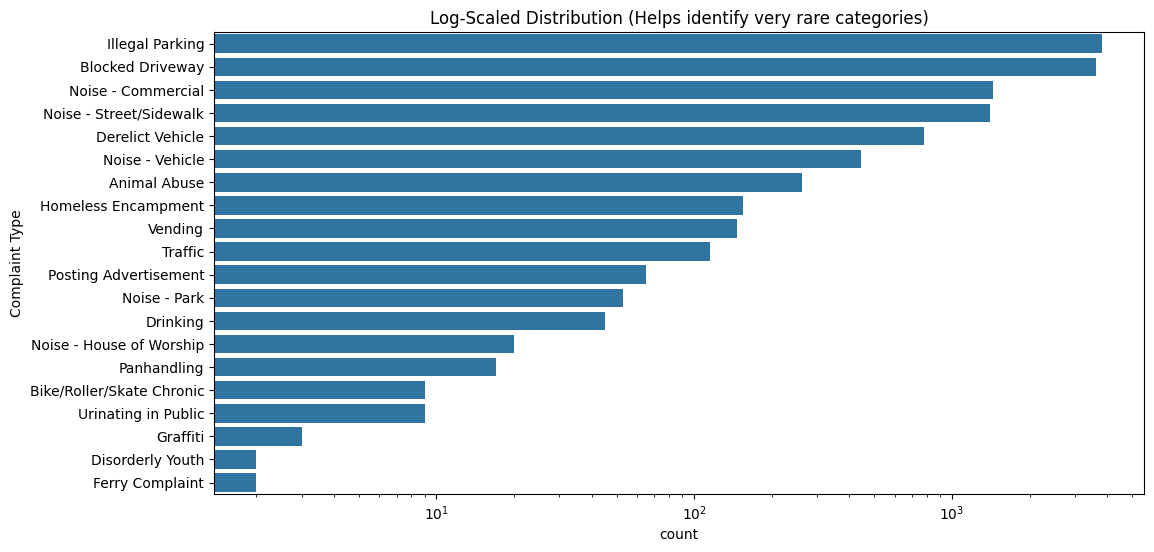

In [3]:
print('Complaint Type value counts:')
print(df['Complaint Type'].value_counts())

# Plotting with a Log Scale to see minority classes
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Complaint Type', order=df['Complaint Type'].value_counts().index)
plt.xscale('log') # This makes the small counts visible
plt.title('Log-Scaled Distribution (Helps identify very rare categories)')
plt.show()

## Hierarchical Label Mapping (Strategic Aggregation)
- To solve the "Long Tail" problem where rare categories have too few samples to train on, we implement **Class Aggregation**. 
- By mapping specific complaints into broad "Super-Departments," we increase data density per category, which significantly improves the F1-Score and model stability.

In [4]:
routing_map = {
    # --- TRANSPORT & STREETS ---
    'Illegal Parking': 'Transport',
    'Blocked Driveway': 'Transport',
    'Derelict Vehicle': 'Transport',
    'Traffic': 'Transport',
    'Vending': 'Transport',
    'Posting Advertisement': 'Transport',
    'Bike/Roller/Skate Chronic': 'Transport',
    
    # --- ENVIRONMENT & NOISE ---
    'Noise - Street/Sidewalk': 'Environment',
    'Noise - Commercial': 'Environment',
    'Noise - Vehicle': 'Environment',
    'Noise - Park': 'Environment',
    'Graffiti': 'Environment', # Grouped here as a Quality of Life/Aesthetic issue
    
    # --- SOCIAL & HEALTH SERVICES ---
    'Animal Abuse': 'Social & Health Services',
    'Homeless Encampment': 'Social & Health Services',
    'Drinking': 'Social & Health Services',
    'Panhandling': 'Social & Health Services',
    'Disorderly Youth': 'Social & Health Services'
}

# Apply the map and drop anything that doesn't fit
df['Department'] = df['Complaint Type'].map(routing_map)
df = df.dropna(subset=['Department']).reset_index(drop=True)

print('[INFO] New Department Distribution:')
print(df['Department'].value_counts())

[INFO] New Department Distribution:
Department
Transport                   8541
Environment                 3335
Social & Health Services     480
Name: count, dtype: int64


## Label Encoding
Since machine learning algorithms operate on mathematical equations, they cannot process text strings directly. We use `LabelEncoder` to translate our "Department" names into integers (0, 1, 2, etc.). This acts as a bridge between human-readable categories and the model's numerical requirements.

In [5]:
le = LabelEncoder()
y = le.fit_transform(df['Department'])
X = df['clean_text'].astype(str)
joblib.dump(le, os.path.join(MODEL_DIR, 'label_encoder.pkl'))

print('Saved label encoder in', MODEL_DIR + 'label_encoder.pkl')

Saved label encoder in ../models/label_encoder.pkl


## Stratified Train/Test Split

In [6]:
# Define features and target
X_raw = df['clean_text']
y_raw = df['Complaint Type']

# Vectorizer should be fit on training data ONLY.
# Using stratified split to maintain class balance.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training Set Size: {X_train_raw.shape[0]}")
print(f"Testing Set Size: {X_test_raw.shape[0]}")

Training Set Size: 9884
Testing Set Size: 2472


## Standardized Pipeline Components

In [7]:
# Define consistent parameters for fair comparison
vectorizer_params = {
    'ngram_range': (1, 2),
    'max_features': 5000,
    'min_df': 3,
    'stop_words': 'english'
}

# Define Model 1: Random Forest
pipeline_rf = Pipeline([
    ('tfidf', TfidfVectorizer(**vectorizer_params)),
    ('clf', RandomForestClassifier(n_estimators=150, max_depth=25, class_weight='balanced', random_state=42, n_jobs=-1))
])

# Define Model 2: Logistic Regression
pipeline_lr = Pipeline([
    ('tfidf', TfidfVectorizer(**vectorizer_params)),
    ('clf', LogisticRegression(solver='saga', max_iter=2000, class_weight='balanced', random_state=42))
])

## Unified Evaluation Logic: Apply CV to BOTH Models

In [8]:
# Use standard cross-validation object and metrics
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro']

# --- Cross-Validation Part 1: Logistic Regression -------
cv_results_lr = cross_validate(pipeline_lr, X_train_raw, y_train, cv=cv, scoring=scoring, n_jobs=-1)

print('Logistic Regression CV Results:')
for m in scoring:
    print(m, f'{cv_results_lr["test_"+m].mean():.4f} +/- {cv_results_lr["test_"+m].std():.4f}')
print('-' * 20)

# --- Cross-Validation Part 2: Random Forest --------
cv_results_rf = cross_validate(pipeline_rf, X_train_raw, y_train, cv=cv, scoring=scoring, n_jobs=-1)

print('Random Forest CV Results:')
for m in scoring:
    print(m, f'{cv_results_rf["test_"+m].mean():.4f} +/- {cv_results_rf["test_"+m].std():.4f}')
print('-' * 20)

Logistic Regression CV Results:
accuracy 0.9994 +/- 0.0007
f1_macro 0.9980 +/- 0.0019
precision_macro 0.9973 +/- 0.0037
recall_macro 0.9987 +/- 0.0011
--------------------
Random Forest CV Results:
accuracy 0.9995 +/- 0.0005
f1_macro 0.9981 +/- 0.0019
precision_macro 0.9974 +/- 0.0036
recall_macro 0.9988 +/- 0.0011
--------------------


## Evaluate Model Function on Test Set
- After cross-validation confirms generalisation, we **retrain each pipeline on the full training split** and evaluate it on the **held-out test set** (20 %).
- The helper `evaluate_on_test()` prints accuracy, a full classification report (precision / recall / F1 per class), and a colour-coded confusion matrix.



  Logistic Regression — Test Set Results
  Overall Accuracy : 0.9996

Classification Report:
                          precision    recall  f1-score   support

             Environment       1.00      1.00      1.00       667
Social & Health Services       1.00      0.99      0.99        96
               Transport       1.00      1.00      1.00      1709

                accuracy                           1.00      2472
               macro avg       1.00      1.00      1.00      2472
            weighted avg       1.00      1.00      1.00      2472



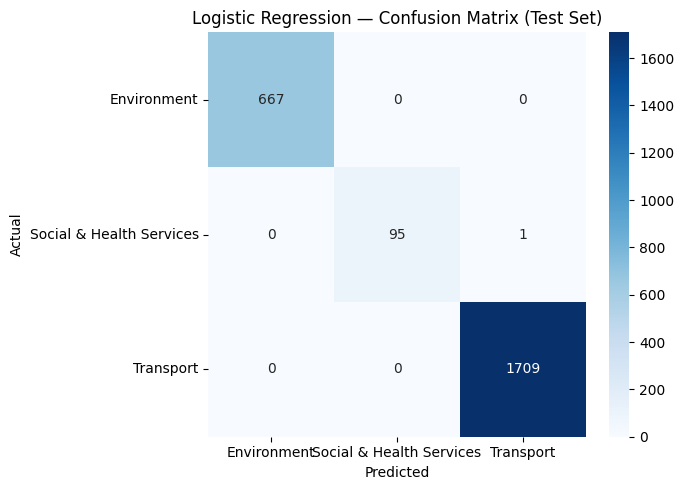


  Random Forest — Test Set Results
  Overall Accuracy : 1.0000

Classification Report:
                          precision    recall  f1-score   support

             Environment       1.00      1.00      1.00       667
Social & Health Services       1.00      1.00      1.00        96
               Transport       1.00      1.00      1.00      1709

                accuracy                           1.00      2472
               macro avg       1.00      1.00      1.00      2472
            weighted avg       1.00      1.00      1.00      2472



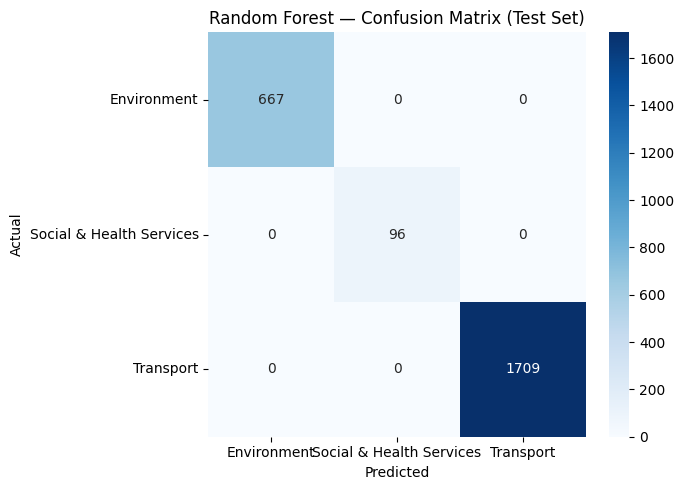

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluate_on_test(pipeline, X_train, y_train, X_test, y_test, label_encoder, model_name='Model'):
    """Fit pipeline on training data, then evaluate on test data."""
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"\n{'='*55}")
    print(f"  {model_name} — Test Set Results")
    print(f"{'='*55}")
    print(f"  Overall Accuracy : {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_, ax=ax)
    ax.set_title(f'{model_name} — Confusion Matrix (Test Set)')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.show()

    return acc, y_pred

# Evaluate both models on the test set
acc_lr, y_pred_lr = evaluate_on_test(
    pipeline_lr, X_train_raw, y_train, X_test_raw, y_test, le, 'Logistic Regression')

acc_rf, y_pred_rf = evaluate_on_test(
    pipeline_rf, X_train_raw, y_train, X_test_raw, y_test, le, 'Random Forest')


## Unified Model Comparison (CV Scores)
A side-by-side summary of the cross-validation metrics and test-set accuracy for both models, making it easy to select the best pipeline.



=== Unified Model Comparison ===
                     CV Accuracy  CV F1 (macro)  CV Precision  CV Recall  CV Accuracy ±  Test Accuracy
Model                                                                                                 
Logistic Regression       0.9994         0.9980        0.9973     0.9987         0.0007         0.9996
Random Forest             0.9995         0.9981        0.9974     0.9988         0.0005         1.0000


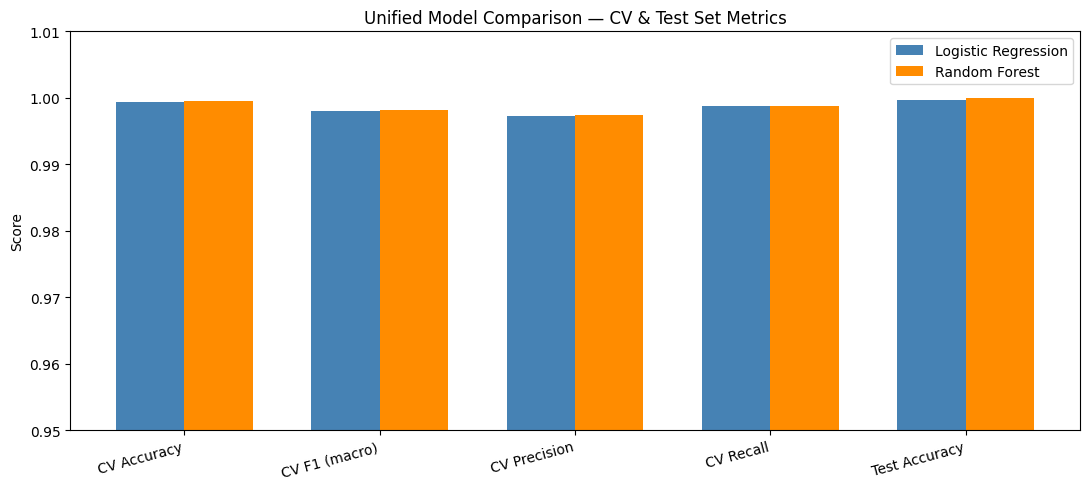

In [10]:
comparison_data = {
    'Model': ['Logistic Regression', 'Random Forest'],
    'CV Accuracy':   [cv_results_lr['test_accuracy'].mean(),    cv_results_rf['test_accuracy'].mean()],
    'CV F1 (macro)': [cv_results_lr['test_f1_macro'].mean(),    cv_results_rf['test_f1_macro'].mean()],
    'CV Precision':  [cv_results_lr['test_precision_macro'].mean(), cv_results_rf['test_precision_macro'].mean()],
    'CV Recall':     [cv_results_lr['test_recall_macro'].mean(), cv_results_rf['test_recall_macro'].mean()],
    'CV Accuracy ±': [cv_results_lr['test_accuracy'].std(),      cv_results_rf['test_accuracy'].std()],
    'Test Accuracy': [acc_lr, acc_rf],
}

comparison_df = pd.DataFrame(comparison_data).set_index('Model').round(4)
print('\n=== Unified Model Comparison ===')
print(comparison_df.to_string())

# Visual bar chart
metrics = ['CV Accuracy', 'CV F1 (macro)', 'CV Precision', 'CV Recall', 'Test Accuracy']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width/2, comparison_df.loc['Logistic Regression', metrics], width, label='Logistic Regression', color='steelblue')
ax.bar(x + width/2, comparison_df.loc['Random Forest',       metrics], width, label='Random Forest',       color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=15, ha='right')
ax.set_ylim(0.95, 1.01)
ax.set_ylabel('Score')
ax.set_title('Unified Model Comparison — CV & Test Set Metrics')
ax.legend()
plt.tight_layout()
plt.show()


## Save Best Model Pipeline
- The model with the higher **test-set accuracy** is automatically designated as the *best* model.
- The full scikit-learn pipeline (TF-IDF vectoriser + classifier) is serialised to `models/best_model_pipeline.pkl` using `joblib`, so it can be loaded and used for inference without re-training.


In [11]:
os.makedirs(MODEL_DIR, exist_ok=True)

# Select best model based on test accuracy
if acc_rf >= acc_lr:
    best_pipeline = pipeline_rf
    best_model_name = 'Random Forest'
    best_acc = acc_rf
else:
    best_pipeline = pipeline_lr
    best_model_name = 'Logistic Regression'
    best_acc = acc_lr

print(f'[INFO] Best model : {best_model_name}  (test accuracy = {best_acc:.4f})')

# Persist the full pipeline (vectoriser + classifier)
pipeline_path = os.path.join(MODEL_DIR, 'best_model_pipeline.pkl')
joblib.dump(best_pipeline, pipeline_path)
print(f'[INFO] Pipeline saved to  : {pipeline_path}')

# Also save a small metadata dict alongside
import json as _json
meta = {
    'best_model': best_model_name,
    'test_accuracy': round(best_acc, 6),
    'classes': list(le.classes_)
}
meta_path = os.path.join(MODEL_DIR, 'model_meta.json')
with open(meta_path, 'w') as _f:
    _json.dump(meta, _f, indent=2)
print(f'[INFO] Metadata saved to  : {meta_path}')


[INFO] Best model : Random Forest  (test accuracy = 1.0000)
[INFO] Pipeline saved to  : ../models/best_model_pipeline.pkl
[INFO] Metadata saved to  : ../models/model_meta.json


## Real-Time Model Validation
Load the saved pipeline from disk and run **live predictions** on arbitrary complaint text.  



[INFO] Loaded pipeline : ../models/best_model_pipeline.pkl
[INFO] Classes         : ['Environment', 'Social & Health Services', 'Transport']

────────────────────────────────────────────────────────────
Complaint                                   → Predicted Department
────────────────────────────────────────────────────────────
Loud music coming from the restaurant ne    → Environment  (61.2%)
Abandoned car parked on the street for o    → Social & Health Services  (47.3%)
Stray dog appears injured and is roaming    → Social & Health Services  (55.6%)
Graffiti tags spray-painted on the bus s    → Social & Health Services  (56.1%)
Person sleeping on park bench and blocki    → Social & Health Services  (51.6%)
Truck illegally parked in front of fire     → Transport  (49.6%)
────────────────────────────────────────────────────────────


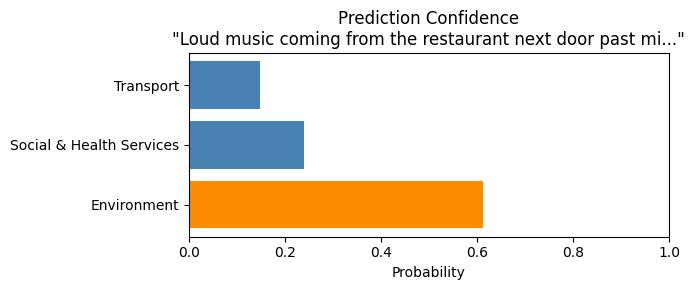

In [12]:
# ── Load artefacts from disk (simulates a fresh deployment) ──────────────────
loaded_pipeline = joblib.load(os.path.join(MODEL_DIR, 'best_model_pipeline.pkl'))
loaded_le       = joblib.load(os.path.join(MODEL_DIR, 'label_encoder.pkl'))

print(f'[INFO] Loaded pipeline : {os.path.join(MODEL_DIR, "best_model_pipeline.pkl")}')
print(f'[INFO] Classes         : {list(loaded_le.classes_)}\n')

# ── Real-time prediction helper ───────────────────────────────────────────────
def predict_department(text, pipeline=loaded_pipeline, encoder=loaded_le):
    """Return the predicted department and per-class probabilities for a complaint."""
    pred_int   = pipeline.predict([text])[0]
    pred_label = encoder.inverse_transform([pred_int])[0]
    proba      = pipeline.predict_proba([text])[0]
    return pred_label, dict(zip(encoder.classes_, proba.round(4)))

# ── Sample complaints to validate ────────────────────────────────────────────
sample_complaints = [
    'Loud music coming from the restaurant next door past midnight',
    'Abandoned car parked on the street for over two weeks',
    'Stray dog appears injured and is roaming the neighbourhood',
    'Graffiti tags spray-painted on the bus shelter walls',
    'Person sleeping on park bench and blocking pedestrian path',
    'Truck illegally parked in front of fire hydrant',
]

print('─' * 60)
print(f'{"Complaint":<42}  {"→ Predicted Department"}')
print('─' * 60)
for complaint in sample_complaints:
    dept, probs = predict_department(complaint)
    top_conf = max(probs.values()) * 100
    print(f'{complaint[:40]:<42}  → {dept}  ({top_conf:.1f}%)')
print('─' * 60)

# ── Probability distribution for a single complaint ──────────────────────────
sample = sample_complaints[0]
dept, probs = predict_department(sample)

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(list(probs.keys()), list(probs.values()), color=['steelblue' if k != dept else 'darkorange' for k in probs])
ax.set_xlim(0, 1)
ax.set_xlabel('Probability')
ax.set_title(f'Prediction Confidence\n"{sample[:55]}..."')
plt.tight_layout()
plt.show()
